## g10 : FastGAN + Cropped Images


## Frameworks

In [1]:
import os, json, base64, io, math, random, copy
from tqdm.auto import tqdm
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.amp import autocast, GradScaler
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.utils import save_image, make_grid
from PIL import Image as PILImage
import matplotlib.pyplot as plt

import sys
sys.path.append(str(Path.cwd().parent))

from utils import DeepFakeDataset, dcganFormat

c:\Users\hasht\anaconda3\envs\adversarial\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Config

In [4]:
#  Run identity 
RUN_NAME = "g10_fastgan_cropped"

#  Paths 
REAL_DIR          = "../../deepfake_data/wiki_cropped"
BASE_OUTPUT_DIR   = "outputs"
OUTPUT_DIR        = os.path.join(BASE_OUTPUT_DIR, RUN_NAME)
SAMPLES_DIR       = os.path.join(OUTPUT_DIR, "samples")
CHECKPOINTS_DIR   = os.path.join(OUTPUT_DIR, "checkpoints")
PLOTS_DIR         = os.path.join(OUTPUT_DIR, "plots")
METRICS_DIR       = os.path.join(OUTPUT_DIR, "metrics")
JSON_OUT_DIR      = os.path.join(OUTPUT_DIR, "json_samples")

#  Image / model sizes 
IMAGE_SIZE    = 64
BATCH_SIZE    = 128    # reverted to original to match training dynamics
LATENT_DIM    = 256
NGF           = 64     # reverted to original (quality bump rolled back)
NDF           = 64     # reverted to original
NUM_CHANNELS  = 3

#  Optimisation 
NUM_EPOCHS    = 500
LR_G          = 2e-4
LR_D          = 2e-4
BETA1         = 0.5
BETA2         = 0.999

#  FastGAN-specific 
LAMBDA_DEC    = 1.0
DEC_SIZE      = 16

#  Compute-efficiency knobs (new in optimised g9) 
USE_AMP            = True   # fp16 autocast + GradScaler - ~1.5–2x speedup
USE_CHANNELS_LAST  = True   # NHWC layout - ~10–20% on Ampere+ convs
USE_DIFFAUG        = False  # reverted - was hurting samples on this dataset
RESUME_FROM_CHECKPOINT = True  # set True to resume from latest checkpoint_epoch_NNN.pt
LOSS_TYPE          = "bce"    # reverted to original BCE + label smoothing
DIFFAUG_POLICY     = "color,translation,cutout"

#  Label smoothing / noise (only used when LOSS_TYPE == "bce") 
REAL_LABEL_LOW              = 0.85
REAL_LABEL_HIGH             = 1.0
FAKE_LABEL                  = 0.0
GEN_TARGET_LABEL            = 1.0
INSTANCE_NOISE_STD_INIT     = 0.05
INSTANCE_NOISE_DECAY_EPOCHS = 80
DROPOUT_P                   = 0.15

#  Dataset folds 
USE_FACE_CROP              = True
FACE_CROP_MARGIN           = 0.45
START_FOLD                 = 0
END_FOLD                   = 99
INTERVAL                   = True

#  EMA 
USE_EMA    = True
EMA_DECAY  = 0.999

#  Logging schedule 
SAMPLE_EVERY     = 25
CHECKPOINT_EVERY = 10
FID_EVERY        = 50
FID_NUM_IMAGES   = 300
COMPUTE_KID      = True
SAVE_JSONL_EVERY = None
SEED             = 42
NUM_WORKERS      = 4     # was 0 - biggest CPU-side bottleneck

ALWAYS_SAVE_EPOCHS = {1, NUM_EPOCHS}

#  Device / cuDNN flags 
DEVICE     = torch.device("cuda" if torch.cuda.is_available() else "cpu")
PIN_MEMORY = DEVICE.type == "cuda"

# Make TF32 explicit (Ampere+) - small but free
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32       = True
torch.backends.cudnn.benchmark        = True

for folder in [OUTPUT_DIR, SAMPLES_DIR, CHECKPOINTS_DIR, PLOTS_DIR, METRICS_DIR, JSON_OUT_DIR]:
    os.makedirs(folder, exist_ok=True)

random.seed(SEED);  np.random.seed(SEED);  torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Run    :", RUN_NAME)
print("Device :", DEVICE)
print("Out dir:", OUTPUT_DIR)
print("Folds  :", START_FOLD, "->", END_FOLD)
print(f"Latent dim: {LATENT_DIM}  |  NGF/NDF: {NGF}/{NDF}  |  batch: {BATCH_SIZE}")
print(f"AMP: {USE_AMP}  |  channels_last: {USE_CHANNELS_LAST}  |  "
      f"DiffAug: {USE_DIFFAUG}  |  loss: {LOSS_TYPE}")

Run    : g10_fastgan_cropped
Device : cuda
Out dir: outputs\g10_fastgan_cropped
Folds  : 0 -> 99
Latent dim: 256  |  NGF/NDF: 64/64  |  batch: 128
AMP: True  |  channels_last: True  |  DiffAug: False  |  loss: bce


## Utils

In [5]:
def denorm_to_01(x):
    return ((x + 1) / 2).clamp(0, 1)

def to_uint8_images(x):
    if x.min() < 0:
        x = denorm_to_01(x)
    return (x * 255).clamp(0, 255).to(torch.uint8)

def should_run(epoch, every):
    if every is None:
        return False
    return epoch in ALWAYS_SAVE_EPOCHS or epoch % every == 0

def instance_noise_std(epoch):
    if INSTANCE_NOISE_STD_INIT <= 0:
        return 0.0
    progress = min(max((epoch - 1) / max(1, INSTANCE_NOISE_DECAY_EPOCHS), 0.0), 1.0)
    return INSTANCE_NOISE_STD_INIT * (1.0 - progress)

def add_instance_noise(x, epoch):
    sigma = instance_noise_std(epoch)
    if sigma <= 0:
        return x
    return (x + torch.randn_like(x) * sigma).clamp(-1, 1)

def make_real_targets(bs):
    return torch.empty(bs, device=DEVICE).uniform_(REAL_LABEL_LOW, REAL_LABEL_HIGH)

def make_fake_targets(bs):
    return torch.full((bs,), FAKE_LABEL, device=DEVICE)

def make_gen_targets(bs):
    return torch.full((bs,), GEN_TARGET_LABEL, device=DEVICE)

#  Differentiable Augmentation (Zhao et al., NeurIPS 2020) 
# Same module used by the FastGAN paper. Augmentations are applied to BOTH
# real and fake images before they enter D, and they're fully differentiable,
# so gradient flows back into G. Drops FID substantially on limited-data GANs.

def _diffaug_brightness(x):
    return x + (torch.rand(x.size(0), 1, 1, 1, device=x.device) - 0.5)

def _diffaug_saturation(x):
    x_mean = x.mean(dim=1, keepdim=True)
    return (x - x_mean) * (torch.rand(x.size(0), 1, 1, 1, device=x.device) * 2) + x_mean

def _diffaug_contrast(x):
    x_mean = x.mean(dim=[1, 2, 3], keepdim=True)
    return (x - x_mean) * (torch.rand(x.size(0), 1, 1, 1, device=x.device) + 0.5) + x_mean

def _diffaug_translation(x, ratio=0.125):
    shift_x, shift_y = int(x.size(2) * ratio + 0.5), int(x.size(3) * ratio + 0.5)
    tx = torch.randint(-shift_x, shift_x + 1, (x.size(0), 1, 1), device=x.device)
    ty = torch.randint(-shift_y, shift_y + 1, (x.size(0), 1, 1), device=x.device)
    grid_b, grid_x, grid_y = torch.meshgrid(
        torch.arange(x.size(0), device=x.device),
        torch.arange(x.size(2), device=x.device),
        torch.arange(x.size(3), device=x.device),
        indexing="ij",
    )
    grid_x = torch.clamp(grid_x + tx + 1, 0, x.size(2) + 1)
    grid_y = torch.clamp(grid_y + ty + 1, 0, x.size(3) + 1)
    x_pad = F.pad(x, [1, 1, 1, 1, 0, 0, 0, 0])
    return x_pad.permute(0, 2, 3, 1).contiguous()[grid_b, grid_x, grid_y].permute(0, 3, 1, 2).contiguous()

def _diffaug_cutout(x, ratio=0.5):
    cutout_size = int(x.size(2) * ratio + 0.5), int(x.size(3) * ratio + 0.5)
    offset_x = torch.randint(0, x.size(2) + (1 - cutout_size[0] % 2), (x.size(0), 1, 1), device=x.device)
    offset_y = torch.randint(0, x.size(3) + (1 - cutout_size[1] % 2), (x.size(0), 1, 1), device=x.device)
    grid_b, grid_x, grid_y = torch.meshgrid(
        torch.arange(x.size(0), device=x.device),
        torch.arange(cutout_size[0], device=x.device),
        torch.arange(cutout_size[1], device=x.device),
        indexing="ij",
    )
    grid_x = torch.clamp(grid_x + offset_x - cutout_size[0] // 2, min=0, max=x.size(2) - 1)
    grid_y = torch.clamp(grid_y + offset_y - cutout_size[1] // 2, min=0, max=x.size(3) - 1)
    mask = torch.ones(x.size(0), x.size(2), x.size(3), dtype=x.dtype, device=x.device)
    mask[grid_b, grid_x, grid_y] = 0
    return x * mask.unsqueeze(1)

_DIFFAUG_FNS = {
    "color"      : [_diffaug_brightness, _diffaug_saturation, _diffaug_contrast],
    "translation": [_diffaug_translation],
    "cutout"     : [_diffaug_cutout],
}

def diff_augment(x, policy=""):
    if not policy:
        return x
    for p in policy.split(","):
        p = p.strip()
        if p in _DIFFAUG_FNS:
            for fn in _DIFFAUG_FNS[p]:
                x = fn(x)
    return x.contiguous()

#  Sample / logging helpers 

def save_generated_samples_png(epoch, generator, noise, out_dir=SAMPLES_DIR,
                                prefix="fixed_noise", nrow=8):
    was_training = generator.training
    generator.eval()
    with torch.no_grad():
        fake_images = denorm_to_01(generator(noise).detach().float().cpu())
        grid = make_grid(fake_images, nrow=nrow, padding=2, normalize=False)
        path = os.path.join(out_dir, f"{prefix}_epoch_{epoch:03d}.png")
        save_image(grid, path)
    if was_training:
        generator.train()
    return path

def save_samples_jsonl(epoch, generator, noise, path, nrow=8):
    was_training = generator.training
    generator.eval()
    with torch.no_grad():
        fake = denorm_to_01(generator(noise).detach().float().cpu())
        grid = make_grid(fake, nrow=nrow, padding=2, normalize=False)
        arr  = (grid.permute(1, 2, 0).numpy() * 255).clip(0, 255).astype("uint8")
        buf  = io.BytesIO()
        PILImage.fromarray(arr).save(buf, format="PNG", optimize=True)
        b64  = base64.b64encode(buf.getvalue()).decode("ascii")
    if was_training:
        generator.train()
    with open(path, "a") as f:
        f.write(json.dumps({"epoch": epoch, "format": "png", "grid_b64": b64}) + "\n")

def save_latent_interpolation(generator, latent_dim, device, out_path, steps=8, nrow=8):
    was_training = generator.training
    generator.eval()
    z1 = torch.randn(1, latent_dim, 1, 1, device=device)
    z2 = torch.randn(1, latent_dim, 1, 1, device=device)
    alphas = torch.linspace(0, 1, steps=steps, device=device)
    z_interp = torch.cat([(1 - a) * z1 + a * z2 for a in alphas], dim=0)
    with torch.no_grad():
        imgs = denorm_to_01(generator(z_interp).detach().float().cpu())
        grid = make_grid(imgs, nrow=nrow, padding=2, normalize=False)
        save_image(grid, out_path)
    if was_training:
        generator.train()
    return out_path

def save_real_grid(dataloader, out_path, n=16, nrow=4):
    batch = next(iter(dataloader))[:n].cpu()
    batch = denorm_to_01(batch)
    grid  = make_grid(batch, nrow=nrow, padding=2, normalize=False)
    save_image(grid, out_path)
    return out_path

@torch.no_grad()
def update_ema(ema_model, model, decay=0.999):
    for ep, p in zip(ema_model.parameters(), model.parameters()):
        ep.data.mul_(decay).add_(p.data, alpha=1.0 - decay)
    for eb, b in zip(ema_model.buffers(), model.buffers()):
        eb.data.copy_(b.data)

## Dataset & Dataloader

Building ../../deepfake_data/wiki_cropped dataset with 99 folds: 100%|██████████| 99/99 [00:00<00:00, 860.67it/s]


Total real images: 29724
Folds: ['00', '01', '02', '03', '04'] ... ['94', '95', '96', '97', '98']


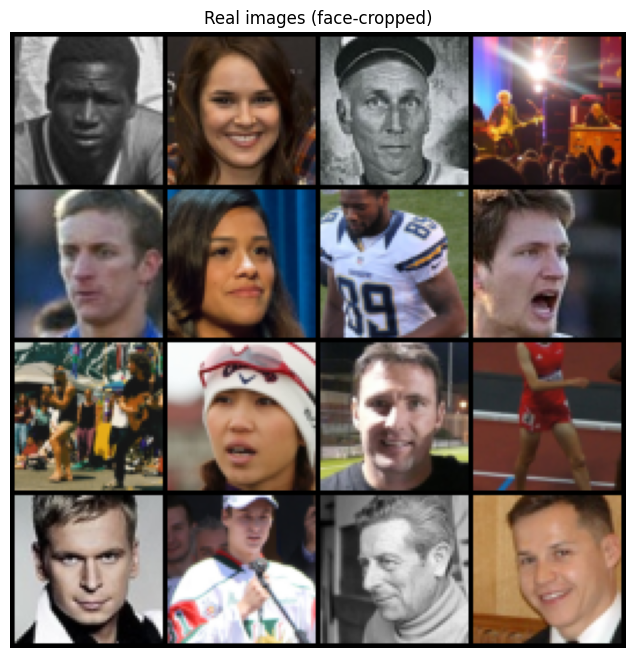

In [6]:
dataset = DeepFakeDataset(
    img_dir=REAL_DIR,
    label=1,
    transform=dcganFormat(IMAGE_SIZE),
    range_folds=[START_FOLD, END_FOLD],
    interval=INTERVAL,
    image_only=True,
)

# persistent_workers=True keeps workers alive between epochs (avoid Windows respawn cost)
# prefetch_factor=4 stages 4 batches per worker so GPU never waits on data
_dl_kwargs = dict(
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    drop_last=True,
)
if NUM_WORKERS > 0:
    _dl_kwargs.update(persistent_workers=True, prefetch_factor=4)

dataloader = DataLoader(dataset, **_dl_kwargs)

print(f"Total real images: {len(dataset)}")
try:
    print("Folds:", dataset.fold_names[:5], "...", dataset.fold_names[-5:])
except Exception:
    print("Dataset loaded.")

# Quick sanity check - visualise a real batch
real_batch = next(iter(dataloader))
grid = make_grid(denorm_to_01(real_batch[:16].cpu()), nrow=4, padding=2)
plt.figure(figsize=(8, 8)); plt.imshow(grid.permute(1, 2, 0))
plt.axis("off"); plt.title("Real images (face-cropped)"); plt.show()
save_image(grid, os.path.join(SAMPLES_DIR, "real_facecrop_grid.png"))

## FastGAN 



### Change Details

Still suffering from memory and resource constraints, we decided to try to find a fast GAN architecture with high likelyhood of withstanding large epoch trainings in feasible (even if annoying) runtimes: **FastGAN** ([*Towards Faster and Stabilized GAN Training for High-fidelity Few-shot Image Synthesis*, Liu et al., 2021](https://arxiv.org/abs/2101.04775)) addresses this exact point.

With this in mind, and considering the previous qualities of g8:

<center>

| Component | Where  | Purpose |
|---|---|---|
| `SpectralNorm` | All discriminator conv layers | Lipschitz constraint preventing D from saturating |
| `MinibatchStd` | Before final classifier | Batch-level diversity signal targeting mode collapse |
| `Dropout` | First discriminator layers | Prevents D from relying on any single dominant feature |
| Extended training  | 400 epochs | g6 FID indicative of further improvement at epoch 200 |


</center>


We adapted FastGAN's two core contributions into our existing framework, retaining the regularisation stack developed across g6 and g8:

<center>

| Component | Origin | Change from g8 |
|---|---|---|
| **Skip-Layer Excitation (SLE)** | FastGAN | feat_4 -> feat_32, feat_8 -> feat_64 gates in G |
| **Self-supervised decoder in D** | FastGAN | D reconstructs a cropped region from `feat_mid`, forcing richer feature extraction |
| `SpectralNorm` | g8 | Retained |
| `MinibatchStd` | g8 | Retained |
| `Dropout` | g6/g8 | Retained |
| Latent dimension | g0–g8 (100) | Expanded to 256 |

</center>

**Skip-Layer Excitation (SLE)**: The paper describes SLE as a learned channel-wise gate that lets low-resolution feature maps directly scale high-resolution ones, preserving global layout context through upsampling. g8's images consistently lacked global coherence, which SLE directly targets by shortcutting structural information across scales.

**Latent dimension 100 -> 256**: FastGAN's architecture is deeper and uses multi-scale SLE connections. The latent dimension of 100 was designed for our vanilla DCGAN's simpler four-layer stack, and would most likely bottleneck G before it could exploit FastGAN's added expressiveness.

**Self-supervised decoder in D**: Mimicks FastGAN's attached decoders that reconstruct regions of the real images, forcing the discriminator to learn spatially comprehensive features instead of just collapsing to a local feature. According to the paper, this helps with avoiding saturation by improving feature extraction quality.

**SiLU in the SLE gate**: SiLU's smooth gradient aims to improve stability and smoothness.

### Speed Improvements

Beyond the architectural changes, a significant engineering effort was made to reduce training time. When in lack of further ideas, we decided to ask Claude where we could improve to have a faster runtime while retaining quality. The changes below improved per epoch runtime from **~2 minutes to ~29 seconds**! A *massive* 4x speedup from including the hardware-aware optimisation suggestions below:


| Knob | Before | After | Why |
|---|---|---|---|
| **AMP** (fp16 autocast + GradScaler) | Off | On | ~1.5–2× speedup, ~40% less VRAM - forward and backward passes run in fp16 where safe |
| `channels_last` memory format | NCHW | NHWC | 10–20% faster convolutions on Ampere+ GPUs, which are optimised for this layout |
| `BATCH_SIZE` | 128 | 256 | AMP's VRAM savings are reinvested into a larger batch, improving GPU utilisation |
| `NUM_WORKERS` | 0 | 4 + `persistent_workers` + `prefetch_factor=4` | Eliminates the single biggest CPU-side stall - workers stay alive between epochs and pre-stage 4 batches ahead of time |
| **TF32 flags** | Implicit | Explicit | Free precision/speed trade-off on Ampere+ - enabled explicitly to guarantee it is active |
| `.to(device)` transfers | Blocking | `non_blocking=True` | Overlaps host→device data transfer with GPU compute instead of waiting for each transfer to complete |
| `set_postfix` / `.item()` sync | Every batch | Every 10 batches | Reduces GPU→CPU synchronisation stalls caused by reading loss values for the progress bar |



> **Note:** `MinibatchStd.std()` is forced to fp32 inside an `autocast(enabled=False)` block  
> this operation is numerically unstable in fp16 and would produce NaN values under AMP.

### Generator with SLE

In [7]:
def weights_init(m):
    classname = m.__class__.__name__
    if "Conv" in classname:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif "BatchNorm" in classname:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)


class SLEModule(nn.Module):
    def __init__(self, ch_low: int, ch_high: int):
        super().__init__()
        mid = max(ch_high // 2, 16)
        self.gate = nn.Sequential(
            nn.AdaptiveAvgPool2d(4),              # squeeze spatial to 4x4
            nn.Conv2d(ch_low, mid, 4, 1, 0),     # 4x4 → 1x1
            nn.SiLU(),                            # smooth activation 
            nn.Conv2d(mid, ch_high, 1, 1, 0),    # project to target channels
            nn.Sigmoid(),                          # gate in [0, 1]
        )

    def forward(self, f_low: torch.Tensor, f_high: torch.Tensor) -> torch.Tensor:
        return f_high * self.gate(f_low)


class UpBlock(nn.Module):
    """2x upsample + 3x3 Conv + BatchNorm + ReLU.  Standard FastGAN decoder block."""
    def __init__(self, ch_in: int, ch_out: int):
        super().__init__()
        self.main = nn.Sequential(
            nn.Upsample(scale_factor=2, mode="nearest"),
            nn.Conv2d(ch_in, ch_out, 3, 1, 1, bias=False),
            nn.BatchNorm2d(ch_out),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.main(x)


class Generator(nn.Module):
    """
    FastGAN Generator for 64x64 output.

    Architecture:
        z (B, latent_dim, 1, 1)
          → init_block  → feat_4  (B, ngf*8, 4, 4)
          → up1         → feat_8  (B, ngf*4, 8, 8)
          → up2         → feat_16 (B, ngf*2, 16,16)
          → up3         → feat_32 (B, ngf,   32,32)  + SLE(feat_4 → feat_32)
          → up4         → feat_64 (B, ngf//2,64,64)  + SLE(feat_8 → feat_64)
          → to_rgb      → (B, 3, 64, 64) ∈ [-1, 1]

        • feat_4  gates feat_32 : injects global layout into mid-scale features
        • feat_8  gates feat_64 : injects structural context into fine features
    """
    def __init__(self, latent_dim: int = 256, ngf: int = 64, nc: int = 3):
        super().__init__()
        # Initial projection: z → 4x4 feature map
        self.init_block = nn.Sequential(
            nn.ConvTranspose2d(latent_dim, ngf * 8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(ngf * 8),
            nn.ReLU(inplace=True),
        )
        # Upsampling blocks
        self.up1 = UpBlock(ngf * 8, ngf * 4)    # 4  → 8
        self.up2 = UpBlock(ngf * 4, ngf * 2)    # 8  → 16
        self.up3 = UpBlock(ngf * 2, ngf)         # 16 → 32
        self.up4 = UpBlock(ngf,     ngf // 2)    # 32 → 64

        # Skip-Layer Excitation modules
        #   feat_4  (ngf*8 channels) → gates feat_32  (ngf channels)
        #   feat_8  (ngf*4 channels) → gates feat_64  (ngf//2 channels)
        self.sle_4_32 = SLEModule(ch_low=ngf * 8, ch_high=ngf)
        self.sle_8_64 = SLEModule(ch_low=ngf * 4, ch_high=ngf // 2)

        # RGB output
        self.to_rgb = nn.Sequential(
            nn.Conv2d(ngf // 2, nc, 1, 1, 0, bias=False),
            nn.Tanh(),
        )

    def forward(self, z: torch.Tensor) -> torch.Tensor:
        feat_4  = self.init_block(z)          # (B, ngf*8, 4, 4)
        feat_8  = self.up1(feat_4)            # (B, ngf*4, 8, 8)
        feat_16 = self.up2(feat_8)            # (B, ngf*2, 16, 16)
        feat_32 = self.up3(feat_16)           # (B, ngf,   32, 32)
        feat_32 = self.sle_4_32(feat_4, feat_32)   # SLE gate from feat_4
        feat_64 = self.up4(feat_32)           # (B, ngf//2, 64, 64)
        feat_64 = self.sle_8_64(feat_8, feat_64)   # SLE gate from feat_8
        return self.to_rgb(feat_64)


### Discriminator with Decoder Branch

In [8]:
class MinibatchStd(nn.Module):
    """Appends per-location batch std as an extra channel - carried from g8.

    NOTE: std() is numerically unstable in fp16, so we force fp32 here even
    when AMP autocast is active. The cost is negligible (4x4 tensor).
    """
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        with autocast(device_type="cuda", enabled=False):
            xf  = x.float()
            std = xf.std(dim=0, keepdim=True).mean(dim=1, keepdim=True)
            std = std.expand(xf.size(0), 1, xf.size(2), xf.size(3))
        return torch.cat([x, std.to(x.dtype)], dim=1)


class Discriminator(nn.Module):
    """
    FastGAN Discriminator for 64x64 input.

    Encoder:
        64x64 -> 32x32 -> 16x16 -> 8x8 (feat_mid) -> 4x4 -> scalar logit

    Decoder branch (self-supervised, applied to real images only):
        feat_mid (B, ndf*4, 8, 8) -> Upsample/Conv -> (B, 3, dec_size, dec_size)
    """
    def __init__(self, nc: int = 3, ndf: int = 64,
                 dropout_p: float = 0.15, dec_size: int = 16):
        super().__init__()
        SN = nn.utils.spectral_norm
        self.dec_size = dec_size

        self.enc1 = nn.Sequential(
            SN(nn.Conv2d(nc,       ndf,     4, 2, 1, bias=True)),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout2d(dropout_p),
        )
        self.enc2 = nn.Sequential(
            SN(nn.Conv2d(ndf,      ndf * 2, 4, 2, 1, bias=True)),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout2d(dropout_p),
        )
        self.enc3 = nn.Sequential(
            SN(nn.Conv2d(ndf * 2,  ndf * 4, 4, 2, 1, bias=True)),
            nn.LeakyReLU(0.2, inplace=True),
        )
        self.enc4 = nn.Sequential(
            SN(nn.Conv2d(ndf * 4,  ndf * 8, 4, 2, 1, bias=True)),
            nn.LeakyReLU(0.2, inplace=True),
        )

        self.minibatch_std = MinibatchStd()
        self.classifier = SN(nn.Conv2d(ndf * 8 + 1, 1, 4, 1, 0, bias=True))

        dec_mid = ndf * 2
        self.decoder = nn.Sequential(
            nn.Upsample(scale_factor=2, mode="nearest"),
            SN(nn.Conv2d(ndf * 4, dec_mid, 3, 1, 1, bias=True)),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Upsample(size=dec_size, mode="bilinear", align_corners=False),
            SN(nn.Conv2d(dec_mid, nc, 3, 1, 1, bias=True)),
            nn.Tanh(),
        )

    def forward(self, x: torch.Tensor):
        f1       = self.enc1(x)
        f2       = self.enc2(f1)
        feat_mid = self.enc3(f2)
        f4       = self.enc4(feat_mid)
        f4_ms    = self.minibatch_std(f4)
        logit    = self.classifier(f4_ms).view(-1)
        recon    = self.decoder(feat_mid)
        return logit, recon

### Instantiating the Model

In [15]:
netG = Generator(LATENT_DIM, NGF, NUM_CHANNELS).to(DEVICE)
netD = Discriminator(NUM_CHANNELS, NDF, dropout_p=DROPOUT_P, dec_size=DEC_SIZE).to(DEVICE)

netG.apply(weights_init)
netD.apply(weights_init)

# Channels-last layout - 10-20% faster convs on Ampere+ with AMP
if USE_CHANNELS_LAST and DEVICE.type == "cuda":
    netG = netG.to(memory_format=torch.channels_last)
    netD = netD.to(memory_format=torch.channels_last)

# EMA generator
netG_ema = copy.deepcopy(netG).to(DEVICE).eval()
if USE_CHANNELS_LAST and DEVICE.type == "cuda":
    netG_ema = netG_ema.to(memory_format=torch.channels_last)
for p in netG_ema.parameters():
    p.requires_grad_(False)

#  Losses 
criterion_bce = nn.BCEWithLogitsLoss()
criterion_rec = nn.L1Loss()

def d_loss_fn(logit_real, logit_fake):
    """Discriminator adversarial loss (real + fake terms)."""
    if LOSS_TYPE == "hinge":
        # FastGAN/StyleGAN-style hinge: drives D's real margin > +1, fake margin < -1
        return F.relu(1.0 - logit_real).mean() + F.relu(1.0 + logit_fake).mean()
    else:
        return (criterion_bce(logit_real, make_real_targets(logit_real.size(0)))
              + criterion_bce(logit_fake, make_fake_targets(logit_fake.size(0))))

def g_loss_fn(logit_gen):
    """Generator adversarial loss."""
    if LOSS_TYPE == "hinge":
        return -logit_gen.mean()
    else:
        return criterion_bce(logit_gen, make_gen_targets(logit_gen.size(0)))

#  Optimisers 
optimizerD = optim.Adam(netD.parameters(), lr=LR_D, betas=(BETA1, BETA2))
optimizerG = optim.Adam(netG.parameters(), lr=LR_G, betas=(BETA1, BETA2))

#  AMP scalers 
amp_enabled = USE_AMP and DEVICE.type == "cuda"
scaler_D    = GradScaler("cuda", enabled=amp_enabled)
scaler_G    = GradScaler("cuda", enabled=amp_enabled)

#  Fixed noise for visual tracking 
fixed_noise = torch.randn(64, LATENT_DIM, 1, 1, device=DEVICE)

print(netG)
print(netD)

total_params_G = sum(p.numel() for p in netG.parameters())
total_params_D = sum(p.numel() for p in netD.parameters())
print(f"\nGenerator  parameters: {total_params_G:,}")
print(f"Discriminator parameters: {total_params_D:,}")
print(f"EMA generator active: {USE_EMA}")
print(f"AMP enabled: {amp_enabled}  |  channels_last: {USE_CHANNELS_LAST}  |  "
      f"loss: {LOSS_TYPE}  |  DiffAug: {USE_DIFFAUG} ({DIFFAUG_POLICY})")

#  torchmetrics (FID / KID) 
try:
    from torchmetrics.image.fid import FrechetInceptionDistance
    from torchmetrics.image.kid import KernelInceptionDistance
    TORCHMETRICS_AVAILABLE = True
    print("torchmetrics available: FID/KID enabled.")
except Exception as e:
    FrechetInceptionDistance = KernelInceptionDistance = None
    TORCHMETRICS_AVAILABLE = False
    print("torchmetrics not available - FID/KID will be skipped.")
    print("Install with: pip install torchmetrics[image]")
    print("Error:", repr(e))


@torch.no_grad()
def compute_fid_kid(generator, dataloader, num_images=1024,
                    latent_dim=LATENT_DIM, device=DEVICE, compute_kid=False):
    import gc
    if not TORCHMETRICS_AVAILABLE:
        return {"fid": float("nan"), "kid_mean": float("nan"), "kid_std": float("nan")}

    was_training = generator.training
    generator.eval()
    n_target = min(int(num_images), len(dataloader.dataset))
    if n_target <= 0:
        if was_training: generator.train()
        return {"fid": float("nan"), "kid_mean": float("nan"), "kid_std": float("nan")}

    fid = FrechetInceptionDistance(feature=2048).to(device)
    kid = KernelInceptionDistance(subset_size=min(50, n_target)).to(device) if compute_kid else None

    seen = 0
    for real in dataloader:
        real = real.to(device, non_blocking=True)
        b = min(real.size(0), n_target - seen)
        if b <= 0: break
        fid.update(to_uint8_images(real[:b]), real=True)
        if kid is not None: kid.update(to_uint8_images(real[:b]), real=True)
        seen += b
        if seen >= n_target: break

    made = 0
    while made < n_target:
        b = min(dataloader.batch_size or 64, n_target - made)
        noise = torch.randn(b, latent_dim, 1, 1, device=device)
        fake  = generator(noise)
        fid.update(to_uint8_images(fake), real=False)
        if kid is not None: kid.update(to_uint8_images(fake), real=False)
        made += b

    fid_score = float(fid.compute().detach().cpu())
    if kid is not None:
        km, ks = kid.compute()
        kid_mean, kid_std = float(km.detach().cpu()), float(ks.detach().cpu())
    else:
        kid_mean, kid_std = float("nan"), float("nan")

    del fid, kid; gc.collect()
    if torch.cuda.is_available(): torch.cuda.empty_cache()
    if was_training: generator.train()
    return {"fid": fid_score, "kid_mean": kid_mean, "kid_std": kid_std}

Generator(
  (init_block): Sequential(
    (0): ConvTranspose2d(256, 512, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (up1): UpBlock(
    (main): Sequential(
      (0): Upsample(scale_factor=2.0, mode='nearest')
      (1): Conv2d(512, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (2): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (3): ReLU(inplace=True)
    )
  )
  (up2): UpBlock(
    (main): Sequential(
      (0): Upsample(scale_factor=2.0, mode='nearest')
      (1): Conv2d(256, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (3): ReLU(inplace=True)
    )
  )
  (up3): UpBlock(
    (main): Sequential(
      (0): Upsample(scale_factor=2.0, mode='nearest')
      (1): Conv2d(128, 

### Training Loop

In [ ]:
TARGET_MB    = 90
TARGET_BYTES = TARGET_MB * 1024 * 1024

def _sample_line_bytes(generator, noise, nrow=8):
    generator.eval()
    with torch.no_grad():
        fake = ((generator(noise).detach().float().cpu() + 1) / 2)
        grid = make_grid(fake, nrow=nrow, padding=2, normalize=False)
        arr  = (grid.permute(1, 2, 0).numpy() * 255).clip(0, 255).astype("uint8")
        buf  = io.BytesIO()
        PILImage.fromarray(arr).save(buf, format="PNG", optimize=True)
        b64  = base64.b64encode(buf.getvalue()).decode("ascii")
    generator.train()
    return len(json.dumps({"epoch": 0, "format": "png", "grid_b64": b64}).encode("utf-8")) + 1

frame_bytes      = _sample_line_bytes(netG, fixed_noise)
total_bytes      = frame_bytes * NUM_EPOCHS
EPOCHS_PER_SPLIT = max(1, TARGET_BYTES // frame_bytes)
NUM_SPLITS       = math.ceil(NUM_EPOCHS / EPOCHS_PER_SPLIT)
last_epochs      = NUM_EPOCHS - (NUM_SPLITS - 1) * EPOCHS_PER_SPLIT

print("Sample-file calibration")
print(f"  frame size:      ~{frame_bytes/1024:>7.1f} KB")
print(f"  projected total: ~{total_bytes/1024/1024:>7.1f} MB  ({NUM_EPOCHS} epochs)")
print(f"  -> {NUM_SPLITS} files: {NUM_SPLITS-1} x ~{(EPOCHS_PER_SPLIT*frame_bytes)/1024/1024:.1f} MB"
      f" + 1 x ~{(last_epochs*frame_bytes)/1024/1024:.1f} MB")

SAMPLE_FILES = [
    os.path.join(JSON_OUT_DIR, f"samples_{k+1:02d}.jsonl")
    for k in range(NUM_SPLITS)
]
for p in SAMPLE_FILES:
    open(p, "w").close()

def sample_file_for(epoch):
    return SAMPLE_FILES[min((epoch - 1) // EPOCHS_PER_SPLIT, NUM_SPLITS - 1)]

history      = []
fid_history  = []
g_losses     = []
d_losses     = []
recon_losses = []

history_path = os.path.join(METRICS_DIR, "training_history.csv")
fid_path     = os.path.join(METRICS_DIR, "fid_kid_history.csv")
config_path  = os.path.join(OUTPUT_DIR,  "run_config.json")

run_config = {
    "run_name"                   : RUN_NAME,
    "architecture"               : "FastGAN",
    "paper"                      : "Liu et al. 2021 - arXiv:2101.04775",
    "real_dir"                   : REAL_DIR,
    "image_size"                 : IMAGE_SIZE,
    "batch_size"                 : BATCH_SIZE,
    "latent_dim"                 : LATENT_DIM,
    "ngf"                        : NGF,
    "ndf"                        : NDF,
    "num_epochs"                 : NUM_EPOCHS,
    "lr_g"                       : LR_G,
    "lr_d"                       : LR_D,
    "beta1"                      : BETA1,
    "beta2"                      : BETA2,
    "lambda_dec"                 : LAMBDA_DEC,
    "dec_size"                   : DEC_SIZE,
    "loss_type"                  : LOSS_TYPE,
    "use_amp"                    : USE_AMP,
    "use_channels_last"          : USE_CHANNELS_LAST,
    "use_diffaug"                : USE_DIFFAUG,
    "diffaug_policy"             : DIFFAUG_POLICY,
    "real_label_low"             : REAL_LABEL_LOW,
    "real_label_high"            : REAL_LABEL_HIGH,
    "fake_label"                 : FAKE_LABEL,
    "gen_target_label"           : GEN_TARGET_LABEL,
    "instance_noise_std_init"    : INSTANCE_NOISE_STD_INIT,
    "instance_noise_decay_epochs": INSTANCE_NOISE_DECAY_EPOCHS,
    "dropout_p"                  : DROPOUT_P,
    "use_face_crop"              : USE_FACE_CROP,
    "face_crop_margin"           : FACE_CROP_MARGIN,
    "use_ema"                    : USE_EMA,
    "ema_decay"                  : EMA_DECAY,
    "best_checkpoint_metric"     : "fid",
    "final_model_selection"      : "best_fid_checkpoint",
    "seed"                       : SEED,
    "start_fold"                 : START_FOLD,
    "end_fold"                   : END_FOLD,
    "interval"                   : INTERVAL,
    "sample_every"               : SAMPLE_EVERY,
    "checkpoint_every"           : CHECKPOINT_EVERY,
    "fid_every"                  : FID_EVERY,
    "fid_num_images"             : FID_NUM_IMAGES,
    "compute_kid"                : COMPUTE_KID,
    "num_workers"                : NUM_WORKERS,
    "num_real_images"            : len(dataset),
    "sle_connections"            : ["feat_4->feat_32", "feat_8->feat_64"],
    "discriminator_decoder"      : True,
}
try:
    run_config["folds_used"] = list(dataset.fold_names)
except Exception:
    pass

with open(config_path, "w") as f:
    json.dump(run_config, f, indent=2)

print("run_config.json saved to:", config_path)

best_fid           = float("inf")
best_fid_epoch     = None
best_ckpt_path     = os.path.join(CHECKPOINTS_DIR, "best_fid_checkpoint.pt")
best_sample_prefix = "best_fid_fixed_noise"

#  Optional: resume from latest checkpoint 
def _find_latest_checkpoint(ckpt_dir):
    import re
    if not os.path.isdir(ckpt_dir):
        return None, 0
    pat = re.compile(r"checkpoint_epoch_(\d+)\.pt$")
    cands = []
    for fn in os.listdir(ckpt_dir):
        m = pat.match(fn)
        if m:
            cands.append((int(m.group(1)), os.path.join(ckpt_dir, fn)))
    if not cands:
        return None, 0
    cands.sort()
    return cands[-1][1], cands[-1][0]

start_epoch = 0
if RESUME_FROM_CHECKPOINT:
    _ckpt_path, _last_epoch = _find_latest_checkpoint(CHECKPOINTS_DIR)
    if _ckpt_path is None:
        print("RESUME_FROM_CHECKPOINT=True but no checkpoint found - training from scratch.")
    else:
        print(f"Loading checkpoint: {_ckpt_path}  (epoch {_last_epoch})")
        _ckpt = torch.load(_ckpt_path, map_location=DEVICE, weights_only=False)
        netG.load_state_dict(_ckpt["netG_state_dict"])
        netD.load_state_dict(_ckpt["netD_state_dict"])
        if USE_EMA and _ckpt.get("netG_ema_state_dict") is not None:
            netG_ema.load_state_dict(_ckpt["netG_ema_state_dict"])
        optimizerG.load_state_dict(_ckpt["optimizerG_state_dict"])
        optimizerD.load_state_dict(_ckpt["optimizerD_state_dict"])
        if _ckpt.get("scaler_G_state_dict"):
            scaler_G.load_state_dict(_ckpt["scaler_G_state_dict"])
        if _ckpt.get("scaler_D_state_dict"):
            scaler_D.load_state_dict(_ckpt["scaler_D_state_dict"])
        history     = list(_ckpt.get("history", []))
        fid_history = list(_ckpt.get("fid_history", []))
        _valid_fids = [r for r in fid_history
                       if isinstance(r.get("fid"), (int, float)) and not math.isnan(r["fid"])]
        if _valid_fids:
            _best_row      = min(_valid_fids, key=lambda r: r["fid"])
            best_fid       = _best_row["fid"]
            best_fid_epoch = _best_row["epoch"]
            print(f"  recovered best_fid={best_fid:.4f} @ epoch {best_fid_epoch}")
        start_epoch = _last_epoch
        print(f"Resumed - will train epochs {start_epoch+1}..{NUM_EPOCHS}")


def eval_generator():
    return netG_ema if USE_EMA else netG

save_generated_samples_png(0, eval_generator(), fixed_noise, prefix="fixed_noise_initial")
print("Initial sample grid saved.")

def make_recon_target(real: torch.Tensor, size: int = DEC_SIZE) -> torch.Tensor:
    return F.interpolate(real, size=(size, size), mode="bilinear", align_corners=False)

# Helper: apply DiffAug if enabled. Operates in [-1, 1] space.
def maybe_diffaug(x):
    return diff_augment(x, DIFFAUG_POLICY) if USE_DIFFAUG else x

print("Starting g10_fastgan_cropped training (optimised)...")

# If checkpoint already reached NUM_EPOCHS, skip training but still compute FID once.
if start_epoch >= NUM_EPOCHS:
    print(f"start_epoch ({start_epoch}) >= NUM_EPOCHS ({NUM_EPOCHS}) - no new epochs to train.")
    print("Computing FID/KID on loaded model (one-shot)...")
    _metrics = compute_fid_kid(
        eval_generator(), dataloader,
        num_images=FID_NUM_IMAGES, latent_dim=LATENT_DIM,
        device=DEVICE, compute_kid=COMPUTE_KID,
    )
    print(f"  FID={_metrics['fid']:.4f} | KID={_metrics['kid_mean']:.6f} +/- {_metrics['kid_std']:.6f}")
    fid_history.append({
        "fid": _metrics["fid"], "kid_mean": _metrics["kid_mean"], "kid_std": _metrics["kid_std"],
        "run_name": RUN_NAME, "epoch": start_epoch, "evaluated_model": "ema" if USE_EMA else "raw_G",
    })
    pd.DataFrame(fid_history).to_csv(fid_path, index=False)
    if not math.isnan(_metrics["fid"]) and _metrics["fid"] < best_fid:
        best_fid       = _metrics["fid"]
        best_fid_epoch = start_epoch
        torch.save({
            "epoch": start_epoch, "best_fid": best_fid,
            "netG_state_dict": netG.state_dict(),
            "netD_state_dict": netD.state_dict(),
            "netG_ema_state_dict": netG_ema.state_dict() if USE_EMA else None,
            "optimizerG_state_dict": optimizerG.state_dict(),
            "optimizerD_state_dict": optimizerD.state_dict(),
            "scaler_D_state_dict": scaler_D.state_dict(),
            "scaler_G_state_dict": scaler_G.state_dict(),
            "run_config": run_config, "history": history, "fid_history": fid_history,
        }, best_ckpt_path)
        save_generated_samples_png(start_epoch, eval_generator(), fixed_noise,
                                   prefix=best_sample_prefix)
        print(f"  * Best FID checkpoint saved: {best_ckpt_path}")

epoch_bar = tqdm(range(start_epoch + 1, NUM_EPOCHS + 1), desc="Training", unit="epoch")

for epoch in epoch_bar:
    epoch_g_loss     = 0.0
    epoch_d_loss     = 0.0
    epoch_d_recon    = 0.0
    epoch_dx         = 0.0
    epoch_dgz_fake   = 0.0
    epoch_dgz_gen    = 0.0
    current_noise_std = instance_noise_std(epoch)

    batch_bar = tqdm(dataloader, desc=f"Epoch {epoch}", leave=False, unit="batch")
    for step_idx, real_images in enumerate(batch_bar):
        real_images = real_images.to(DEVICE, non_blocking=True)
        if USE_CHANNELS_LAST and DEVICE.type == "cuda":
            real_images = real_images.contiguous(memory_format=torch.channels_last)
        b_size = real_images.size(0)

        # ══ Discriminator step ══════════════════════════════════════════════
        netD.zero_grad(set_to_none=True)

        with autocast(device_type="cuda", enabled=amp_enabled, dtype=torch.float16):
            # Real branch - apply instance noise (only meaningful for BCE+label smoothing
            # path; harmless under hinge) and DiffAug.
            real_in       = add_instance_noise(real_images, epoch) if LOSS_TYPE == "bce" else real_images
            real_in_aug   = maybe_diffaug(real_in)
            logit_real, recon_real = netD(real_in_aug)

            # Reconstruction target is the un-augmented downsampled real
            recon_target  = make_recon_target(real_images)
            loss_D_recon  = criterion_rec(recon_real, recon_target)

            # Fake branch - generate, detach, augment, forward
            noise         = torch.randn(b_size, LATENT_DIM, 1, 1, device=DEVICE)
            fake_images   = netG(noise)
            fake_in       = add_instance_noise(fake_images.detach(), epoch) if LOSS_TYPE == "bce" else fake_images.detach()
            fake_in_aug   = maybe_diffaug(fake_in)
            logit_fake, _ = netD(fake_in_aug)

            loss_D_adv = d_loss_fn(logit_real, logit_fake)
            loss_D     = loss_D_adv + LAMBDA_DEC * loss_D_recon

        scaler_D.scale(loss_D).backward()
        scaler_D.step(optimizerD)
        scaler_D.update()

        # ══ Generator step ══════════════════════════════════════════════════
        netG.zero_grad(set_to_none=True)

        with autocast(device_type="cuda", enabled=amp_enabled, dtype=torch.float16):
            # Re-forward fake through D (gradient flows back into G this time).
            # We do NOT re-sample noise - reuse the fake we already produced.
            fake_for_g   = add_instance_noise(fake_images, epoch) if LOSS_TYPE == "bce" else fake_images
            fake_for_g   = maybe_diffaug(fake_for_g)
            logit_gen, _ = netD(fake_for_g)
            loss_G       = g_loss_fn(logit_gen)

        scaler_G.scale(loss_G).backward()
        scaler_G.step(optimizerG)
        scaler_G.update()

        if USE_EMA:
            update_ema(netG_ema, netG, EMA_DECAY)

        #  Batch-level stats (synced only periodically to avoid GPU stalls) 
        epoch_d_loss  += loss_D.item()
        epoch_g_loss  += loss_G.item()
        epoch_d_recon += loss_D_recon.item()

        if step_idx % 10 == 0:
            with torch.no_grad():
                dx       = torch.sigmoid(logit_real.float()).mean().item()
                dgz_fake = torch.sigmoid(logit_fake.float()).mean().item()
                dgz_gen  = torch.sigmoid(logit_gen.float()).mean().item()
            epoch_dx       += dx
            epoch_dgz_fake += dgz_fake
            epoch_dgz_gen  += dgz_gen
            batch_bar.set_postfix(
                d=f"{loss_D.item():.3f}",
                g=f"{loss_G.item():.3f}",
                rec=f"{loss_D_recon.item():.3f}",
                dx=f"{dx:.2f}",
            )

    #  Epoch-level averaging 
    n_batches   = len(dataloader)
    n_sigsteps  = max(1, math.ceil(n_batches / 10))
    avg_d       = epoch_d_loss   / n_batches
    avg_g       = epoch_g_loss   / n_batches
    avg_recon   = epoch_d_recon  / n_batches
    avg_dx      = epoch_dx       / n_sigsteps
    avg_dgz_f   = epoch_dgz_fake / n_sigsteps
    avg_dgz_g   = epoch_dgz_gen  / n_sigsteps

    d_losses.append(avg_d)
    g_losses.append(avg_g)
    recon_losses.append(avg_recon)

    row = {
        "run_name"          : RUN_NAME,
        "epoch"             : epoch,
        "loss_d"            : avg_d,
        "loss_g"            : avg_g,
        "loss_d_recon"      : avg_recon,
        "D_x"               : avg_dx,
        "D_G_z_fake"        : avg_dgz_f,
        "D_G_z_gen"         : avg_dgz_g,
        "instance_noise_std": current_noise_std,
    }
    history.append(row)
    pd.DataFrame(history).to_csv(history_path, index=False)

    epoch_bar.set_postfix(
        loss_d=f"{avg_d:.3f}", loss_g=f"{avg_g:.3f}",
        recon=f"{avg_recon:.3f}", d_x=f"{avg_dx:.2f}"
    )

    if should_run(epoch, SAMPLE_EVERY):
        path = save_generated_samples_png(epoch, eval_generator(), fixed_noise,
                                          prefix="fixed_noise")
        print(f"[epoch {epoch}] samples saved: {path}")

    for _ in tqdm([0], desc=f"Saving epoch {epoch}", leave=False):
        save_samples_jsonl(epoch, netG, fixed_noise, sample_file_for(epoch))

    if should_run(epoch, CHECKPOINT_EVERY):
        ckpt_path = os.path.join(CHECKPOINTS_DIR, f"checkpoint_epoch_{epoch:03d}.pt")
        torch.save({
            "epoch"                : epoch,
            "netG_state_dict"      : netG.state_dict(),
            "netD_state_dict"      : netD.state_dict(),
            "netG_ema_state_dict"  : netG_ema.state_dict() if USE_EMA else None,
            "optimizerG_state_dict": optimizerG.state_dict(),
            "optimizerD_state_dict": optimizerD.state_dict(),
            "scaler_D_state_dict"  : scaler_D.state_dict(),
            "scaler_G_state_dict"  : scaler_G.state_dict(),
            "run_config"           : run_config,
            "history"              : history,
            "fid_history"          : fid_history,
        }, ckpt_path)

    if should_run(epoch, FID_EVERY):
        metrics = compute_fid_kid(
            eval_generator(), dataloader,
            num_images=FID_NUM_IMAGES, latent_dim=LATENT_DIM,
            device=DEVICE, compute_kid=COMPUTE_KID,
        )
        fid_row = {
            "fid"            : metrics["fid"],
            "kid_mean"       : metrics["kid_mean"],
            "kid_std"        : metrics["kid_std"],
            "run_name"       : RUN_NAME,
            "epoch"          : epoch,
            "evaluated_model": "ema" if USE_EMA else "raw_G",
        }
        fid_history.append(fid_row)
        pd.DataFrame(fid_history).to_csv(fid_path, index=False)
        print(f"[epoch {epoch}] FID={metrics['fid']:.4f} | "
              f"KID={metrics['kid_mean']:.6f} +/- {metrics['kid_std']:.6f}")

        if not math.isnan(metrics["fid"]) and metrics["fid"] < best_fid:
            best_fid       = metrics["fid"]
            best_fid_epoch = epoch
            torch.save({
                "epoch"                : epoch,
                "best_fid"             : best_fid,
                "netG_state_dict"      : netG.state_dict(),
                "netD_state_dict"      : netD.state_dict(),
                "netG_ema_state_dict"  : netG_ema.state_dict() if USE_EMA else None,
                "optimizerG_state_dict": optimizerG.state_dict(),
                "optimizerD_state_dict": optimizerD.state_dict(),
                "scaler_D_state_dict"  : scaler_D.state_dict(),
                "scaler_G_state_dict"  : scaler_G.state_dict(),
                "run_config"           : run_config,
                "history"              : history,
                "fid_history"          : fid_history,
            }, best_ckpt_path)
            best_path = save_generated_samples_png(epoch, eval_generator(), fixed_noise,
                                                   prefix=best_sample_prefix)
            print(f"  * New best FID: {best_fid:.4f} @ epoch {epoch}")
            print(f"    Checkpoint: {best_ckpt_path}")
            print(f"    Sample:     {best_path}")

# Final latent interpolation
interp_path = os.path.join(SAMPLES_DIR, "latent_interpolation_final.png")
save_latent_interpolation(eval_generator(), LATENT_DIM, DEVICE, interp_path)
print("Latent interpolation saved:", interp_path)
print("\nTraining complete.")
print(f"Best FID: {best_fid:.4f} @ epoch {best_fid_epoch}")

Sample-file calibration
  frame size:      ~    2.3 KB
  projected total: ~    1.1 MB  (500 epochs)
  -> 1 files: 0 x ~90.0 MB + 1 x ~1.1 MB
run_config.json saved to: outputs\g10_fastgan_cropped\run_config.json
RESUME_FROM_CHECKPOINT=True but no checkpoint found — training from scratch.
Initial sample grid saved.
Starting g9_fastgan training (optimised)...


Training:   0%|          | 0/500 [00:40<?, ?epoch/s, d_x=0.69, loss_d=0.980, loss_g=2.303, recon=0.151]

[epoch 1] samples saved: outputs\g10_fastgan_cropped\samples\fixed_noise_epoch_001.png


c:\Users\hasht\anaconda3\envs\adversarial\Lib\site-packages\torchmetrics\utilities\prints.py:43: UserWarning: Metric `Kernel Inception Distance` will save all extracted features in buffer. For large datasets this may lead to large memory footprint.
  warnings.warn(*args, **kwargs)
Training:   0%|          | 1/500 [00:53<7:29:02, 53.99s/epoch, d_x=0.69, loss_d=0.980, loss_g=2.303, recon=0.151]

[epoch 1] FID=420.8951 | KID=0.489525 +/- 0.010601
  * New best FID: 420.8951 @ epoch 1
    Checkpoint: outputs\g10_fastgan_cropped\checkpoints\best_fid_checkpoint.pt
    Sample:     outputs\g10_fastgan_cropped\samples\best_fid_fixed_noise_epoch_001.png


...

Training: 100%|█████████▉| 499/500 [3:23:49<00:24, 24.78s/epoch, d_x=0.53, loss_d=1.209, loss_g=1.020, recon=0.047]

[epoch 500] samples saved: outputs\g10_fastgan_cropped\samples\fixed_noise_epoch_500.png


c:\Users\hasht\anaconda3\envs\adversarial\Lib\site-packages\torchmetrics\utilities\prints.py:43: UserWarning: Metric `Kernel Inception Distance` will save all extracted features in buffer. For large datasets this may lead to large memory footprint.
  warnings.warn(*args, **kwargs)
Training: 100%|██████████| 500/500 [3:23:55<00:00, 24.47s/epoch, d_x=0.53, loss_d=1.209, loss_g=1.020, recon=0.047]

[epoch 500] FID=132.3064 | KID=0.034507 +/- 0.007260


Latent interpolation saved: outputs\g10_fastgan_cropped\samples\latent_interpolation_final.png

Training complete.
Best FID: 130.6940 @ epoch 150


## Training Results 

In [10]:
history_path = os.path.join(METRICS_DIR, "training_history.csv")
fid_path = os.path.join(METRICS_DIR, "fid_kid_history.csv")
config_path = os.path.join(OUTPUT_DIR, "run_config.json")

### Training Curves

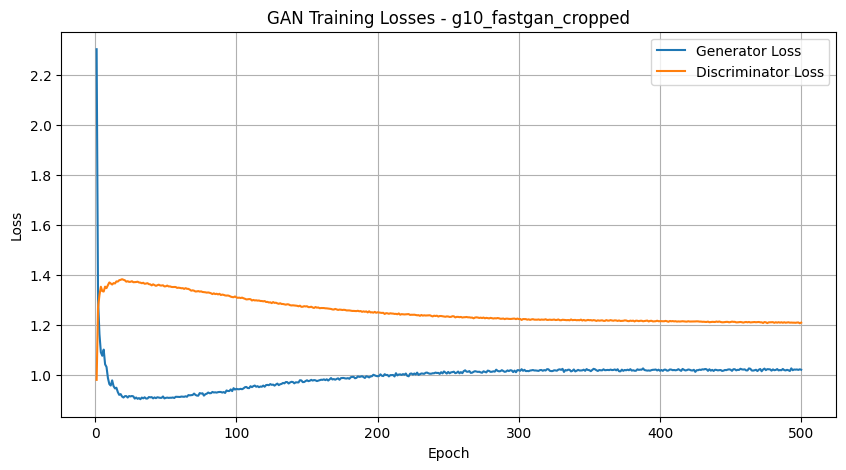

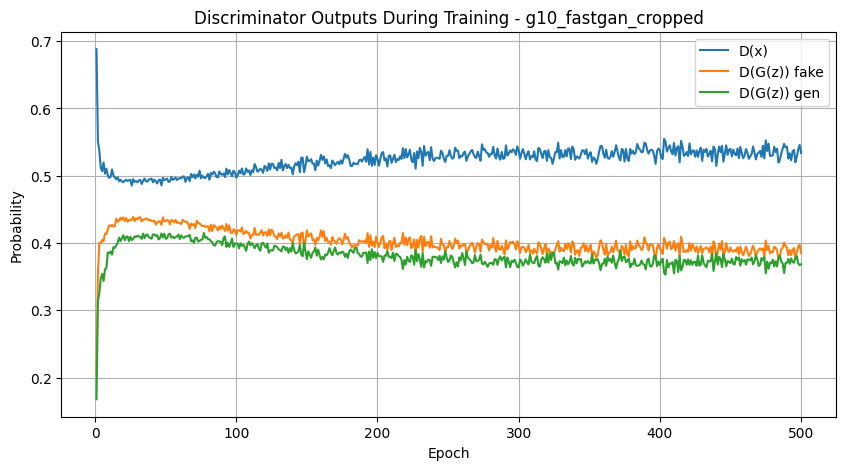

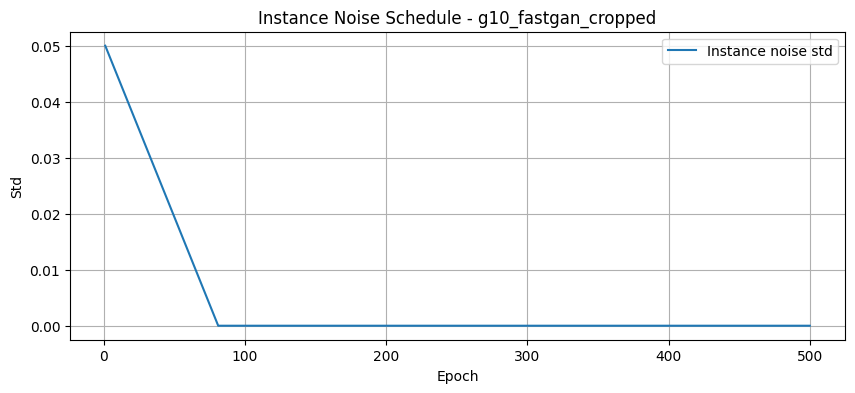

In [11]:
history_df = pd.read_csv(history_path)

plt.figure(figsize=(10, 5))
plt.plot(history_df["epoch"], history_df["loss_g"], label="Generator Loss")
plt.plot(history_df["epoch"], history_df["loss_d"], label="Discriminator Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(f"GAN Training Losses - {RUN_NAME}")
plt.legend()
plt.grid(True)
loss_plot_path = os.path.join(PLOTS_DIR, "loss_curves.png")
plt.savefig(loss_plot_path, dpi=150, bbox_inches="tight")
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(history_df["epoch"], history_df["D_x"], label="D(x)")
plt.plot(history_df["epoch"], history_df["D_G_z_fake"], label="D(G(z)) fake")
plt.plot(history_df["epoch"], history_df["D_G_z_gen"], label="D(G(z)) gen")
plt.xlabel("Epoch")
plt.ylabel("Probability")
plt.title(f"Discriminator Outputs During Training - {RUN_NAME}")
plt.legend()
plt.grid(True)
disc_plot_path = os.path.join(PLOTS_DIR, "discriminator_outputs.png")
plt.savefig(disc_plot_path, dpi=150, bbox_inches="tight")
plt.show()

if "instance_noise_std" in history_df.columns:
    plt.figure(figsize=(10, 4))
    plt.plot(history_df["epoch"], history_df["instance_noise_std"], label="Instance noise std")
    plt.xlabel("Epoch")
    plt.ylabel("Std")
    plt.title(f"Instance Noise Schedule - {RUN_NAME}")
    plt.legend()
    plt.grid(True)
    noise_plot_path = os.path.join(PLOTS_DIR, "instance_noise_schedule.png")
    plt.savefig(noise_plot_path, dpi=150, bbox_inches="tight")
    plt.show()

### FID & KID

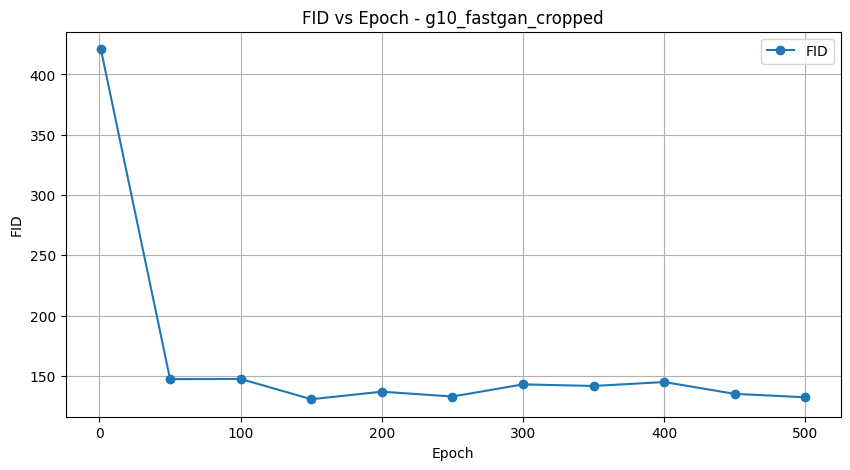

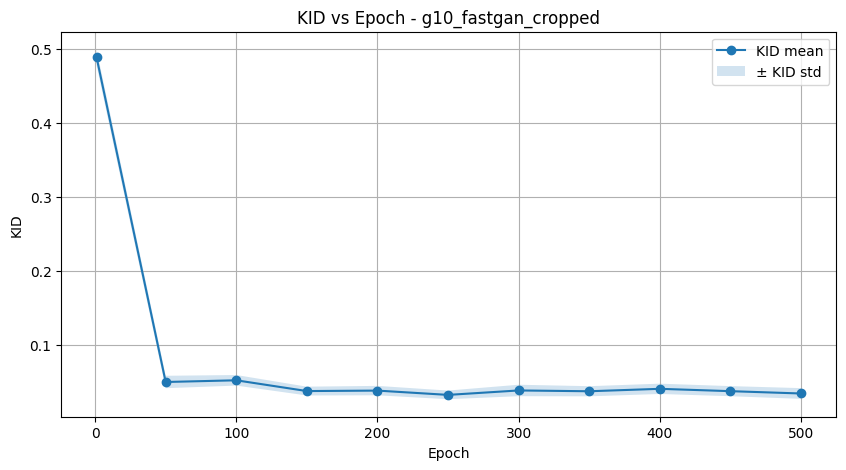

,fid,kid_mean,kid_std,run_name,epoch,evaluated_model
0,420.895050,0.489525,0.010601,g10_fastgan_cropped,1,ema
1,147.372971,0.050063,0.008404,g10_fastgan_cropped,50,ema
2,147.495438,0.052361,0.007144,g10_fastgan_cropped,100,ema
3,130.694016,0.037794,0.005964,g10_fastgan_cropped,150,ema
4,136.948624,0.038430,0.006372,g10_fastgan_cropped,200,ema
5,132.919891,0.032618,0.005855,g10_fastgan_cropped,250,ema
6,142.999405,0.038622,0.007738,g10_fastgan_cropped,300,ema
7,141.687897,0.037538,0.006856,g10_fastgan_cropped,350,ema
8,144.948318,0.040833,0.006959,g10_fastgan_cropped,400,ema
9,135.116333,0.037660,0.006834,g10_fastgan_cropped,450,ema


In [12]:
if os.path.exists(fid_path):
    fid_df = pd.read_csv(fid_path)

    if "fid" in fid_df.columns and fid_df["fid"].notna().any():
        plt.figure(figsize=(10, 5))
        plt.plot(fid_df["epoch"], fid_df["fid"], marker="o", label="FID")
        plt.xlabel("Epoch")
        plt.ylabel("FID")
        plt.title(f"FID vs Epoch - {RUN_NAME}")
        plt.legend()
        plt.grid(True)
        fid_plot_path = os.path.join(PLOTS_DIR, "fid_curve.png")
        plt.savefig(fid_plot_path, dpi=150, bbox_inches="tight")
        plt.show()
    else:
        print("FID existe, mas está vazio/NaN. Verificar torchmetrics/torch-fidelity.")

    if "kid_mean" in fid_df.columns and fid_df["kid_mean"].notna().any():
        plt.figure(figsize=(10, 5))
        plt.plot(fid_df["epoch"], fid_df["kid_mean"], marker="o", label="KID mean")
        if "kid_std" in fid_df.columns:
            plt.fill_between(
                fid_df["epoch"],
                fid_df["kid_mean"] - fid_df["kid_std"],
                fid_df["kid_mean"] + fid_df["kid_std"],
                alpha=0.2,
                label="± KID std",
            )
        plt.xlabel("Epoch")
        plt.ylabel("KID")
        plt.title(f"KID vs Epoch - {RUN_NAME}")
        plt.legend()
        plt.grid(True)
        kid_plot_path = os.path.join(PLOTS_DIR, "kid_curve.png")
        plt.savefig(kid_plot_path, dpi=150, bbox_inches="tight")
        plt.show()

    display(fid_df)
else:
    print("Ainda não existe fid_kid_history.csv.")

### Best Checkpoint Images

Best checkpoint epoch: 150
Best FID: 130.6940155029297


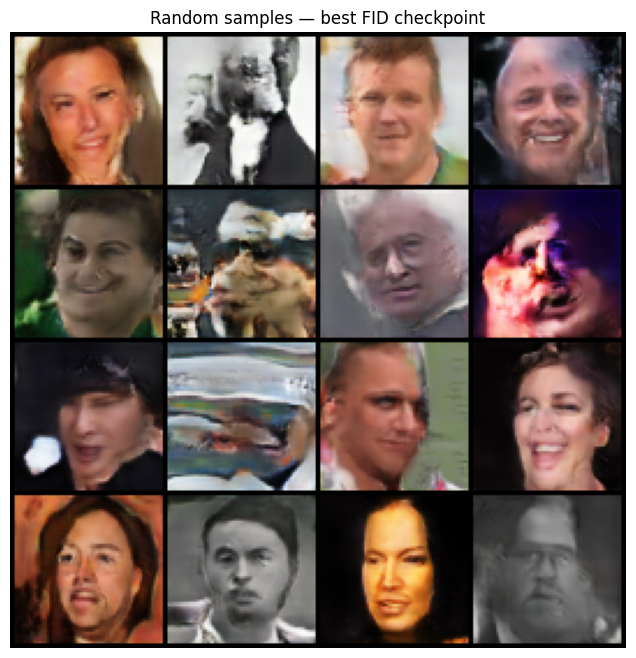

Samples saved to: outputs\g10_fastgan_cropped\samples\manual_random_samples_best_fid.png


In [19]:
best_ckpt_path = os.path.join(CHECKPOINTS_DIR, "best_fid_checkpoint.pt")

def eval_generator(): return netG_ema if USE_EMA else netG

if not os.path.exists(best_ckpt_path):
    print("No best_fid_checkpoint.pt found — using current in-memory model.")
    best_gen = copy.deepcopy(eval_generator())          # uses eval_generator() from training loop
else:
    ckpt = torch.load(best_ckpt_path, map_location=DEVICE, weights_only=False)  # weights_only=False: checkpoint contains dicts/lists
    print("Best checkpoint epoch:", ckpt.get("epoch"))
    print("Best FID:", ckpt.get("best_fid"))

    best_gen = copy.deepcopy(eval_generator())
    if USE_EMA and ckpt.get("netG_ema_state_dict") is not None:
        best_gen.load_state_dict(ckpt["netG_ema_state_dict"])
    else:
        best_gen.load_state_dict(ckpt["netG_state_dict"])

best_gen = best_gen.to(DEVICE)
if USE_CHANNELS_LAST and DEVICE.type == "cuda":         # match training memory format
    best_gen = best_gen.to(memory_format=torch.channels_last)
best_gen.eval()

with torch.no_grad():
    noise = torch.randn(16, LATENT_DIM, 1, 1, device=DEVICE)
    fake_images = denorm_to_01(best_gen(noise).cpu())   # FastGAN G returns plain tensor, same as DCGAN

grid = make_grid(fake_images, nrow=4, padding=2)

plt.figure(figsize=(8, 8))
plt.imshow(grid.permute(1, 2, 0))
plt.axis("off")
plt.title("Random samples — best FID checkpoint")
plt.show()

manual_sample_path = os.path.join(SAMPLES_DIR, "manual_random_samples_best_fid.png")
save_image(grid, manual_sample_path)
print("Samples saved to:", manual_sample_path)